In [147]:
import sys
from typing import Tuple
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from cloudforger.core.records import to_pointcloud
from cloudforger.core.io import load_pickle

from cloudforger.core.cloud import PointCloud
from cloudforger.core.region import Box
from cloudforger.data_generation.point_processes.poisson import PoissonProcess

OUT = ROOT / "notebooks" / "out"
OUT.mkdir(parents=True, exist_ok=True)

cloud_path = "/Users/qp252676/Desktop/point-process-tda/data/nested_thomas/clouds.pkl"

In [148]:
raw_cloud = load_pickle(cloud_path)[1]
cloud = to_pointcloud(raw_cloud)

In [149]:
def indie_thinning(points: np.ndarray, p: float = 0.25) -> np.ndarray:
    if not (0 <= p <= 1):
        raise ValueError("p must be in [0, 1]")
    mask = np.random.rand(points.shape[0]) < p
    return points[mask]


def poisson(points: np.ndarray, p: float = 0.25) -> np.ndarray:
    n_points = points.shape[0]
    region = Box(low=np.zeros(2), high=np.ones(2))
    p_noise = PoissonProcess(intensity=(1-p)*n_points).sample(region=region)

    return np.concatenate([points, p_noise.points], axis=0)

def gaussian_jitter(points: np.ndarray, sigma: float = 0.01) -> np.ndarray:
    noise = np.random.normal(loc=0.0, scale=sigma, size=points.shape)
    return points + noise

def flow_wrapper(cloud: PointCloud, steps: int = 10, p: float = 0.25) -> Tuple[np.ndarray, ...]:
    points = cloud.points
    progression = [points]
    for _ in range(steps):
        thinned = indie_thinning(points=progression[-1], p=p)
        if thinned.shape[0] == 0:
            break
        jittered = gaussian_jitter(points=thinned, sigma=0.01)
        poissoned = poisson(points=jittered, p=p)
        progression.append(poissoned)

    return progression

def graphing(cloud: PointCloud) -> None:
    pts = cloud.points
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.6, color="tab:blue", linewidths=0)

    if cloud.region is not None:
        low, high = cloud.region.low, cloud.region.high
        ax.set_xlim(low[0], high[0])
        ax.set_ylim(low[1], high[1])

    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{cloud.generator_name} point cloud (n={cloud.n_points})")
    ax.grid(True, alpha=0.2)
    fig.tight_layout()
    fig.savefig(OUT / "point_cloud.png", dpi=150)
    plt.show()

In [150]:
progression = flow_wrapper(cloud=cloud, p=0.99, steps=1000)

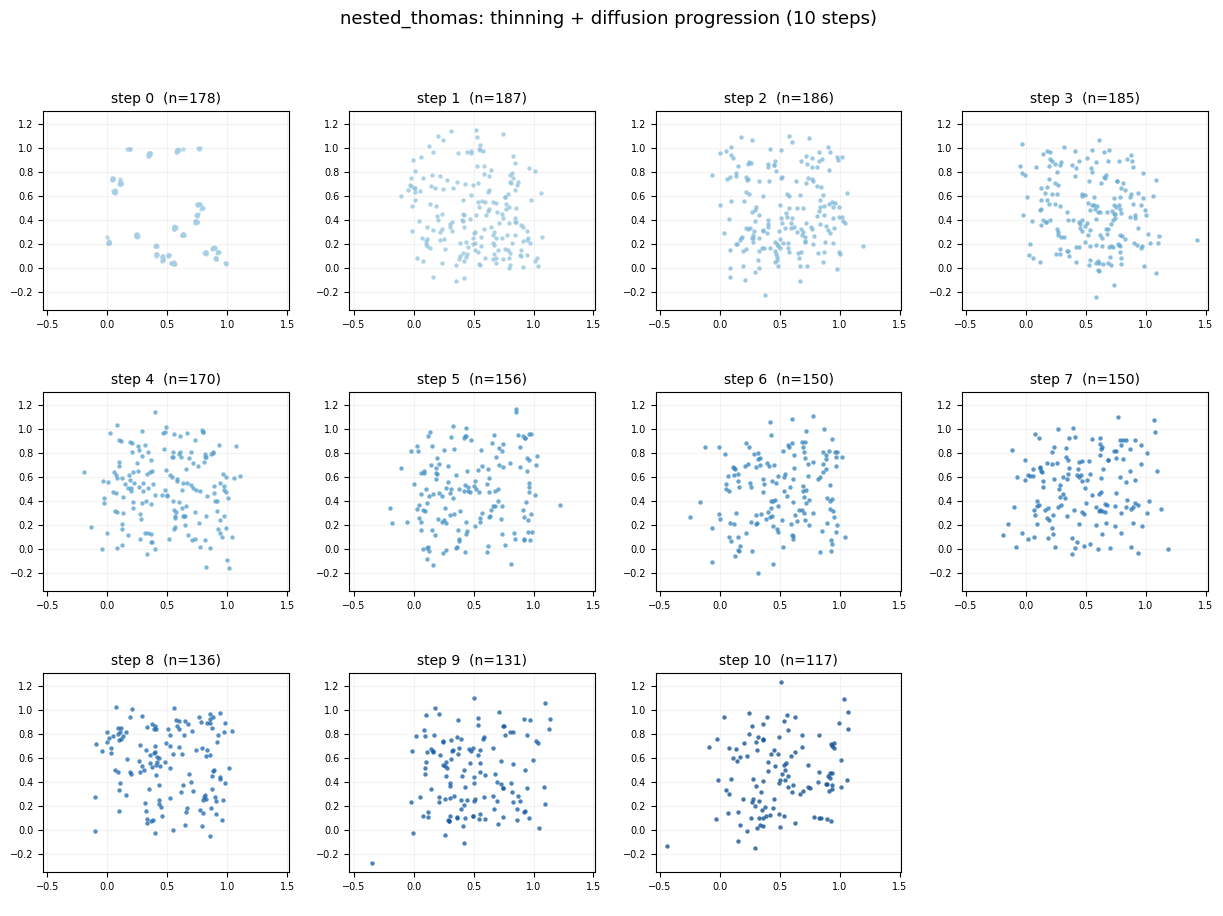

In [151]:
progression_thin = []

for i in range(len(progression)):
    if i == 0:
        progression_thin.append(progression[i])
    elif i % 100 == 0:
        progression_thin.append(progression[i])

n_frames = len(progression_thin)
n_cols = min(4, n_frames)
n_rows = int(np.ceil(n_frames / n_cols))

# shared bounds across every frame, so panels are directly comparable
all_pts = np.vstack(progression_thin)
pad_x = 0.05 * np.ptp(all_pts[:, 0])
pad_y = 0.05 * np.ptp(all_pts[:, 1])
xlim = (all_pts[:, 0].min() - pad_x, all_pts[:, 0].max() + pad_x)
ylim = (all_pts[:, 1].min() - pad_y, all_pts[:, 1].max() + pad_y)

# sequential single-hue ramp: light -> dark encodes step index
cmap = plt.cm.Blues
colors = [cmap(0.35 + 0.55 * i / max(n_frames - 1, 1)) for i in range(n_frames)]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.1 * n_cols, 3.1 * n_rows), squeeze=False)

for i, ax in enumerate(axes.flat):
    if i >= n_frames:
        ax.axis("off")
        continue
    pts = progression_thin[i]
    ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.75, color=colors[i], linewidths=0)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.set_title(f"step {i}  (n={len(pts)})", fontsize=10)
    ax.grid(True, alpha=0.15)
    ax.tick_params(labelsize=7)

fig.suptitle(f"{cloud.generator_name}: thinning + diffusion progression ({n_frames - 1} steps)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUT / "progression.png", dpi=150)
plt.show()